<a href="https://colab.research.google.com/github/Apeetha-Srinivasan/Apeetha-Srinivasan/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os


In [8]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)
print("Dataset location:", data_dir)

data_dir = os.path.join(data_dir, "flower_photos")

print(data_dir)
print(os.listdir(data_dir))



Dataset location: /root/.keras/datasets/flower_photos
/root/.keras/datasets/flower_photos/flower_photos
['roses', 'daisy', 'dandelion', 'LICENSE.txt', 'tulips', 'sunflowers']


In [9]:
img_size=(128,128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size = img_size,
    batch_size = batch_size,
    validation_split = 0.2,
    subset = "training",
    seed = 42
)

val_ds= tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size = img_size,
    batch_size = batch_size,
    validation_split = 0.2,
    subset = "validation",
    seed = 42

)

class_names = train_ds.class_names
print(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [10]:
model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')

])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.2554 - loss: 17.2355 - val_accuracy: 0.2738 - val_loss: 1.5801
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.3447 - loss: 1.4874 - val_accuracy: 0.2670 - val_loss: 1.5595
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.3954 - loss: 1.3764 - val_accuracy: 0.3270 - val_loss: 1.5578
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.4550 - loss: 1.2692 - val_accuracy: 0.3052 - val_loss: 1.7648
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5085 - loss: 1.1244 - val_accuracy: 0.3093 - val_loss: 2.0326
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.5995 - loss: 0.9703 - val_accuracy: 0.3283 - val_loss: 2.0268
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6659 - loss: 0.8106 - val_accuracy: 0.3379 - val_loss: 2.4365
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7187 - loss: 0.7240 - val_accuracy: 0.3174 - 

In [20]:
img = load_img(
    "/new_flower.jpg",
    target_size=(128,128)
)

img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, axis = 0)

In [21]:
test_loss, test_accuracy = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 354ms/step - accuracy: 0.3338 - loss: 3.6500
Test Loss: 3.6500184535980225
Test Accuracy: 0.3337874710559845


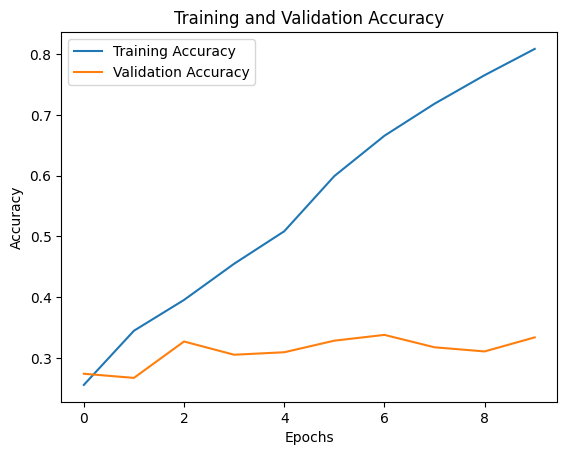

In [22]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

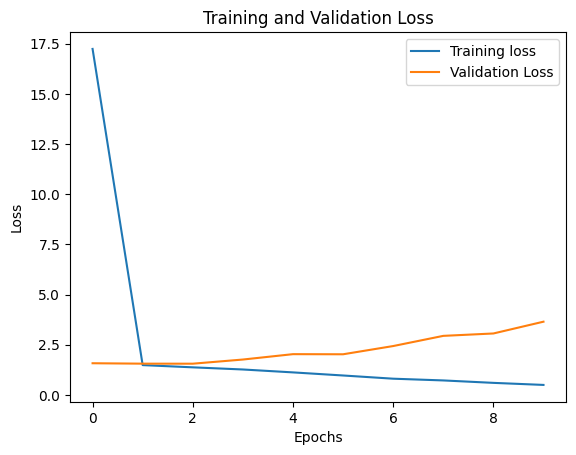

In [23]:
plt.plot(history.history['loss'], label = "Training loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [24]:
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Predicted Flower:", predicted_class)
print("Confidence:", confidence)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Predicted Flower: roses
Confidence: 52.353622
